In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Import Datasets

In [2]:
gt: np.ndarray = np.load("C:\\Users\\fabis\\OneDrive\\Dokumente\\Studium\\SoSe_26\\Projekt\\fMRI preprocessing and dataset generation-20260324\\gt_list.npy", allow_pickle=True)
print(gt.shape)

degraded: np.ndarray = np.load("C:\\Users\\fabis\\OneDrive\\Dokumente\\Studium\\SoSe_26\\Projekt\\fMRI preprocessing and dataset generation-20260324\\degraded_list.npy", allow_pickle=True)
print(degraded.shape)


(5,)
(5,)


## Erstelle Chunks für Volume 0...

In [3]:
def split_3d(volume, chunk_size):
    x, y, z = volume.shape
    cx, cy, cz = chunk_size
    
    chunks = []
    
    for i in range(0, x, cx):
        for j in range(0, y, cy):
            for k in range(0, z, cz):
                chunk = volume[i:i+cx, j:j+cy, k:k+cz]
                
                # nur vollständige Chunks behalten
                if chunk.shape == (cx, cy, cz):
                    chunks.append(chunk)
                    
    return np.array(chunks)

### Ground Truth

In [4]:
# get volume 0
volume_gt = gt[0]
print(volume_gt.shape)

all_chunks_gt = []
chunks = (32, 32, 21)

for i in range(volume_gt.shape[3]): # iterate over time
    
    resulting_3d_img_gt = volume_gt[:, :, :, i] # get 3d img per timestep
    result_gt = split_3d(resulting_3d_img_gt, chunks) # get volume data per time
    all_chunks_gt.append(result_gt)


all_chunks_gt = np.array(all_chunks_gt)
print(all_chunks_gt.shape)
# 5d array: time, chunks per time, 3d width, height, slices

# lose temporal context 
data_gt = all_chunks_gt.reshape(-1, 32, 32, 21)
data_gt = data_gt[:, None, ...]  # channel dimension hinzufügen

print(data_gt.shape)


(128, 128, 84, 262)
(262, 64, 32, 32, 21)
(16768, 1, 32, 32, 21)


### Degraded

In [5]:
# get volume 0
volume_dg = degraded[0]
print(volume_dg.shape)

all_chunks_dg = []
chunks = (32, 32, 21)

for i in range(volume_dg.shape[3]): # iterate over time
    
    resulting_3d_img_dg = volume_dg[:, :, :, i] # get 3d img per timestep
    result_dg = split_3d(resulting_3d_img_dg, chunks) # get volume data per time
    all_chunks_dg.append(result_dg)


all_chunks_dg = np.array(all_chunks_dg)
print(all_chunks_dg.shape)
# 5d array: time, chunks per time, 3d width, height, slices

# lose temporal context 
data_dg = all_chunks_dg.reshape(-1, 32, 32, 21)
data_dg = data_dg[:, None, ...]  # channel dimension hinzufügen

print(data_dg.shape)


(128, 128, 84, 262)
(262, 64, 32, 32, 21)
(16768, 1, 32, 32, 21)


Visualize same Ground Truth and Degraded image...

(32, 32)


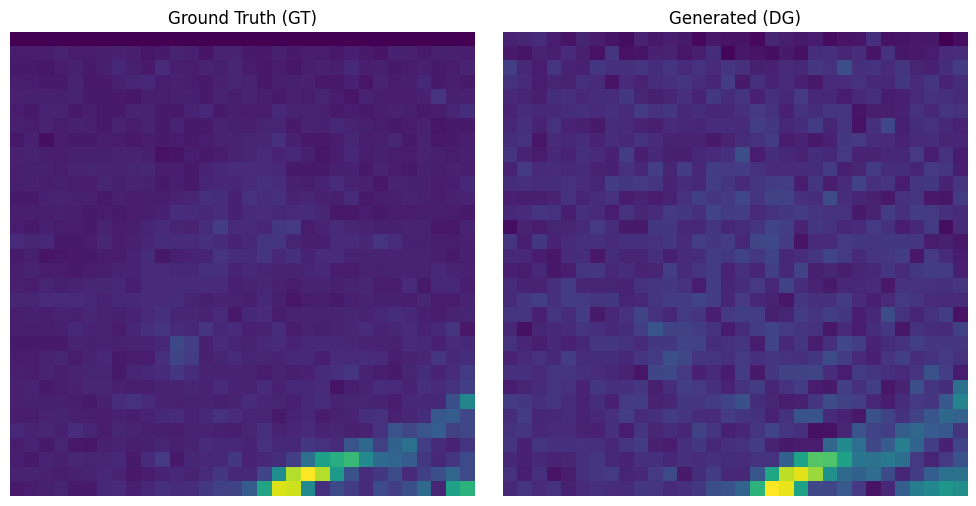

In [6]:
 # get the first image with slice 0
img_gt = data_gt[0, 0, :, :, 0]
img_dg = data_dg[0, 0, :, :, 0]

print(img_gt.shape)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gt)
plt.title("Ground Truth (GT)")
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(img_dg)
plt.title("Generated (DG)")
plt.axis('off')

plt.tight_layout()
plt.show()

Define Dataset, Dataloader, preprocessing for model